### PMSM 2D thermal study with convection
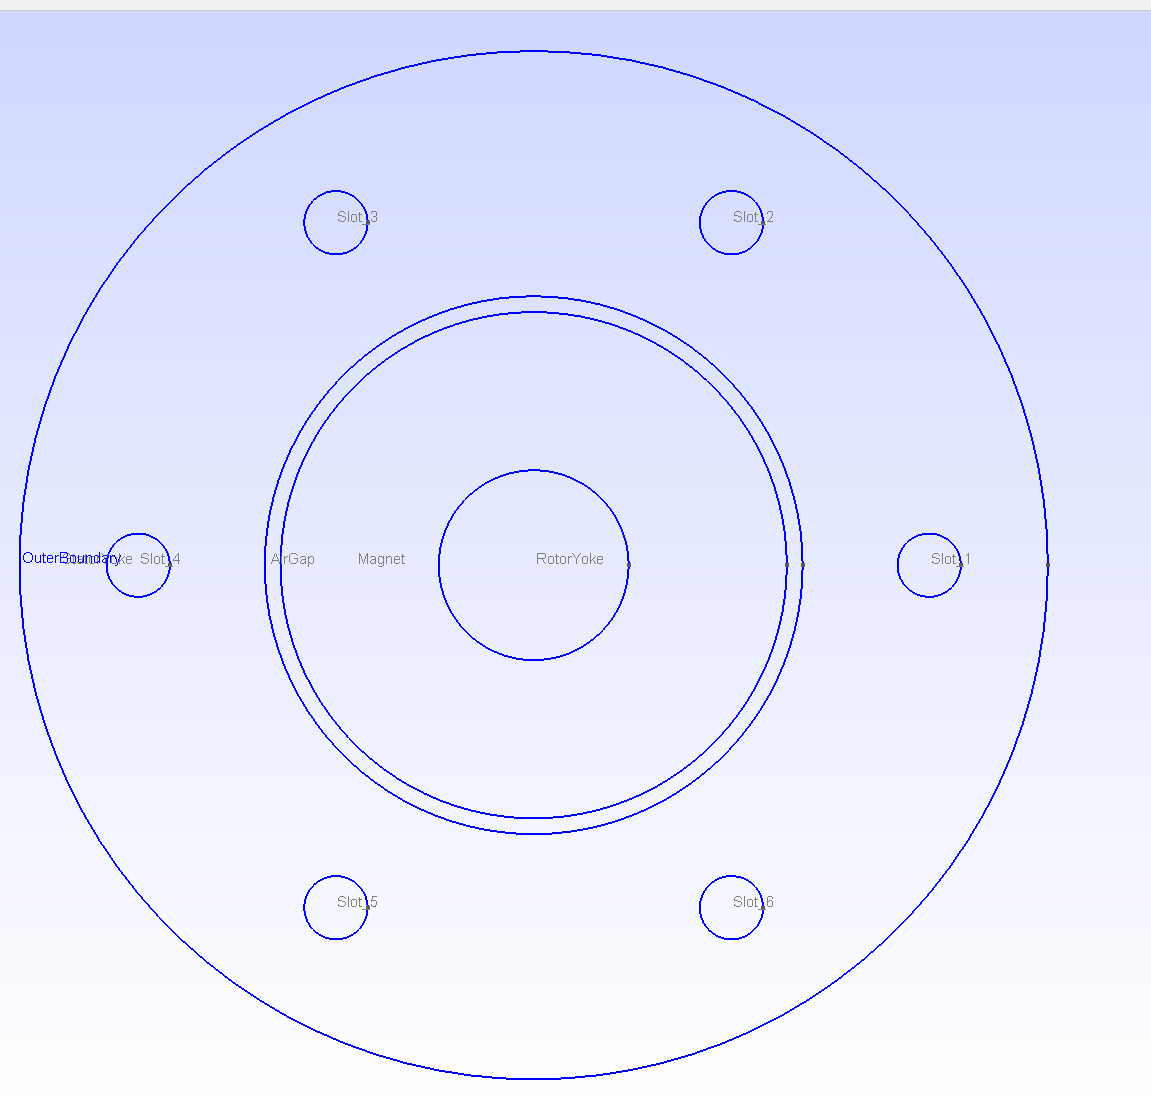

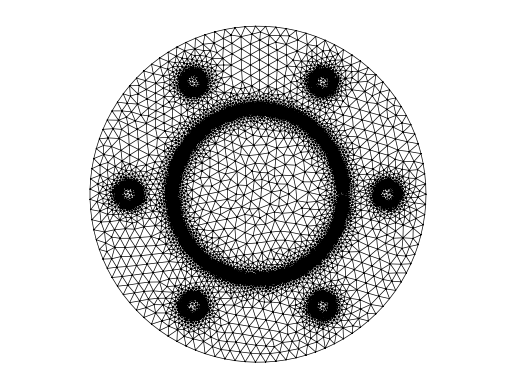

In [2]:
import meshio
from skfem import *
from skfem.helpers import dot, grad
import numpy as np

from skfem.io.meshio import from_meshio

# Add repository root to Python path. Helps to find files and modules
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))

m = meshio.read("mesh/mesh_pmsm_2d.msh")

mesh = from_meshio(m)

from skfem.visuals.matplotlib import draw
import matplotlib.pyplot as plt

draw(mesh)
plt.axis("equal")
plt.show()


In [3]:
from skfem import Basis, ElementTriP2

# Second order tringular elements.
e = ElementTriP2()
basis = Basis(mesh, e, intorder=4)

basis_rotor_yoke = basis.with_elements(mesh.subdomains["RotorYoke"])
basis_stator_yoke = basis.with_elements(mesh.subdomains["StatorYoke"])
basis_air_gap = basis.with_elements(mesh.subdomains["AirGap"])
basis_magnet = basis.with_elements(mesh.subdomains["Magnet"])


from skfem import FacetBasis

# MST line intgral path. Circe in the middle of airgap
basis_robin_bnd = FacetBasis(
    mesh,
    basis.elem,
    facets=mesh.boundaries["OuterBoundary"]
)


# Slot to phzse current mapping
"""
Slot_1 → A+
Slot_2 → B−
Slot_3 → C+
Slot_4 → A−
Slot_5 → B+
Slot_6 → C−
"""

slot_bases = [
    basis.with_elements(mesh.subdomains[f"Slot_{i}"])
    for i in range(1, 7)
]


# Test plate area
from skfem import Functional
@Functional
def area(w):
    return 1.0

print()
slot_area = area.assemble(slot_bases[0])
print("In units of m: ", slot_area)


In units of m:  5.007820143519473e-05


# Formulation

We are trying to solve temperature distribution in the pmsm motor T(x,y) in steady state conditions. We have slots as heat sources, and outer boundary has convection boundary condition.

### Steady-state heat conduction

The steady-state heat equation is

$$
-\nabla \cdot \left(k \nabla T\right) = Q
\qquad \text{in } \Omega,
$$

where

- $T$ is the temperature [K],
- $k$ is the thermal conductivity [W/(m K)],
- $Q$ is the volumetric heat generation [W/m$^3$],
- $\Omega$ is the computational domain.


# Boundary conditions

### Robin boundary condition / Convection BC

Convection to an ambient environment is described by

$$
-k\nabla T \cdot \mathbf n
=
h(T-T_\infty)
\qquad \text{on } \Gamma_R,
$$

where

- $h$ is the convection coefficient [W/(m$^2$ K)],
- $T_\infty$ is the ambient temperature [K].

We add this into weak form of heat equations, which turns out to be after multiplying test function and integration py parts:

$$
\boxed{
\int_\Omega
k\nabla v\cdot\nabla T\,d\Omega
=
\int_\Omega vQ\,d\Omega
+
\int_\Gamma
v\,k\nabla T\cdot\mathbf n\,d\Gamma
}
$$


### Robin boundary

The Robin boundary condition is

$$
-k\nabla T\cdot\mathbf n
=
h(T-T_\infty).
$$

Rearranging,

$$
k\nabla T\cdot\mathbf n
=
-h(T-T_\infty).
$$

Expanding,

$$
k\nabla T\cdot\mathbf n
=
-hT+hT_\infty.
$$

Substituting into the weak form gives

$$
\int_{\Gamma_R}
v\,k\nabla T\cdot\mathbf n\,d\Gamma
=
\int_{\Gamma_R}
v(-hT+hT_\infty)\,d\Gamma.
$$

Therefore,

$$
\boxed{
\int_\Omega
k\nabla v\cdot\nabla T\,d\Omega
+
\int_{\Gamma_R}
hvT\,d\Gamma
=
\int_\Omega vQ\,d\Omega
+
\int_{\Gamma_R}
hvT_\infty\,d\Gamma
}
$$

We notice:
- First term traditional conductivity matrix / stiffness matrix
- Second term, coupling convection from boundary to the domain nodes. Looks like mass matrix, but only in boundary nodes
- Third term, source term where the heat is generated
- Fourth term: Neumann term, defines heat flux on boundary. T_inf is known.


In [ ]:
### Material parameters:
k_air = 0.026 # W/(m*K)       / Air
k_pm = 8 # W/(m*K)            / NdFeB
k_rotor_yoke = 30 # W/(m*K)   / Electrical steel
k_stator_yoke = 30 # W/(m*K)  / Electrical steel
k_slot = 380 # W/(m*K)        / Copper

sigma_slot = 5.8e7  # S/m     / Copper

### Heat sources:

# Copper losses Q = J^2/sigma
I_0 = 2
Nturns = 100
J_rms = I_0 * Nturns / (np.sqrt(2) * slot_area) # A/m^2

#Q_slot = J_rms**2 / sigma_slot # W/m^3 
print(Q_slot)
Q_pm = 0.0 # W/m^3
Q_air = 0.0 # W/m^3
Q_iron = 1e5  # W/m^3
Q_iron = 0.0  # W/m^3
#Q_slot = 0.0


# Convection params for ambient air
h_air = 10.0          # W/(m^2 K)  
T_inf = 20.0+273.15      # K


### ASSEMBLE SYSTEM


# First term: conductivity matrix
@BilinearForm
def conductivity_matrix(A, v, w):
    return w.k*dot(grad(A), grad(v))


K = conductivity_matrix.assemble(basis_rotor_yoke, k=k_rotor_yoke)
K += conductivity_matrix.assemble(basis_stator_yoke, k=k_stator_yoke)
K += conductivity_matrix.assemble(basis_air_gap, k=k_air)
K += conductivity_matrix.assemble(basis_magnet, k=k_pm)

# Slots (air-filled)
for basis_i in slot_bases:
    K += conductivity_matrix.assemble(basis_i, k=k_slot)

# Second term: Robin boundary condition matrix,  coupling domain temperature to ambient temperature
@BilinearForm
def robin_matrix(A, v, w):
    return w.h*A*v

K += robin_matrix.assemble(basis_robin_bnd, h=h_air)

# Third term: heat source vector
@LinearForm
def heat_source_vector(v, w):
    return w.Q * v

f = heat_source_vector.assemble(basis_rotor_yoke, Q=Q_iron)
f += heat_source_vector.assemble(basis_stator_yoke, Q=Q_iron)
f += heat_source_vector.assemble(basis_air_gap, Q=Q_air)
f += heat_source_vector.assemble(basis_magnet, Q=Q_pm)
# Copper losses in slots
for basis_i in slot_bases:
    f += heat_source_vector.assemble(basis_i, Q=Q_slot)

# Fourth term: Neumann boundary condition vector, how much heat is leaving system to ambient air.
@LinearForm
def neumann_BC(v, w):
    return w.q_n * v

# We define normal vector as outward pointing ,  so q_n = +h*T_inf means heat is leaving the motor to domain
f += neumann_BC.assemble(
    basis_robin_bnd,
    q_n=h_air*T_inf
)


T = solve(K, f)


137500.58839666407


Visualize

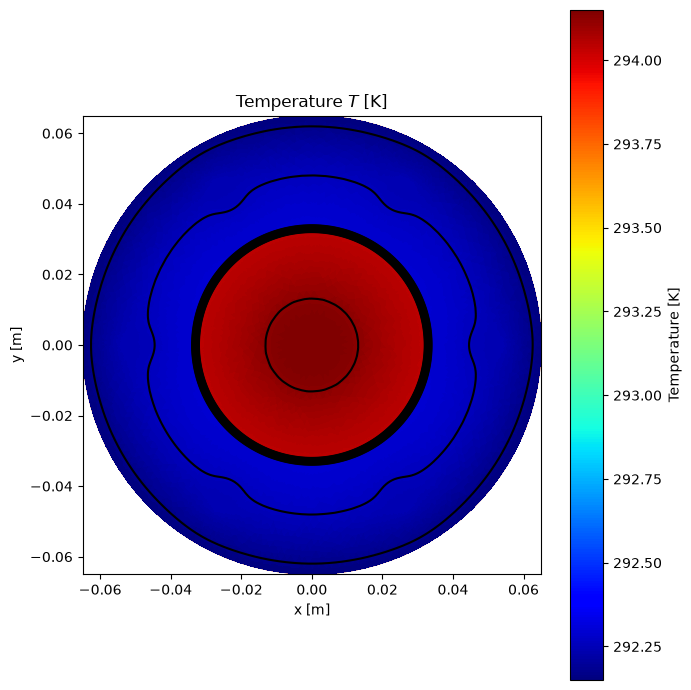

T_inf = 293.15
T_min = 532.5684278468278
T_max = 551.4048991320134
T_mean = 538.6939092478444
max error = 258.2548991320134


In [19]:
import matplotlib.pyplot as plt
from skfem.visuals.matplotlib import plot

fig, ax = plt.subplots(figsize=(7, 7))

# Temperature field + colorbar
plot(
    basis,
    T,
    shading="gouraud",
    colorbar=True,
    ax=ax,
    vmin=T_inf - 1,
    vmax=T_inf + 1,
)

# Temperature contour lines
plot(
    basis,
    T,
    ax=ax,
    levels=30,
    color="black",
    linewidths=0.4,
)

# Axis formatting
ax.set_aspect("equal")
ax.set_title(r"Temperature $T$ [K]")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")

# The colorbar created by scikit-fem is the second axes
# in the figure: [main plot, colorbar]
cbar = fig.axes[-1]
cbar.set_ylabel("Temperature [K]")

plt.tight_layout()
plt.show()

print("T_inf =", T_inf)
print("T_min =", np.min(T))
print("T_max =", np.max(T))
print("T_mean =", np.mean(T))
print("max error =", np.max(np.abs(T - T_inf)))

Lets solve the heat **q**. Should be form hot -> cold 

Mean |q| = 6400.000000 W/m²
Std  |q| = 1.365945e-10 W/m²


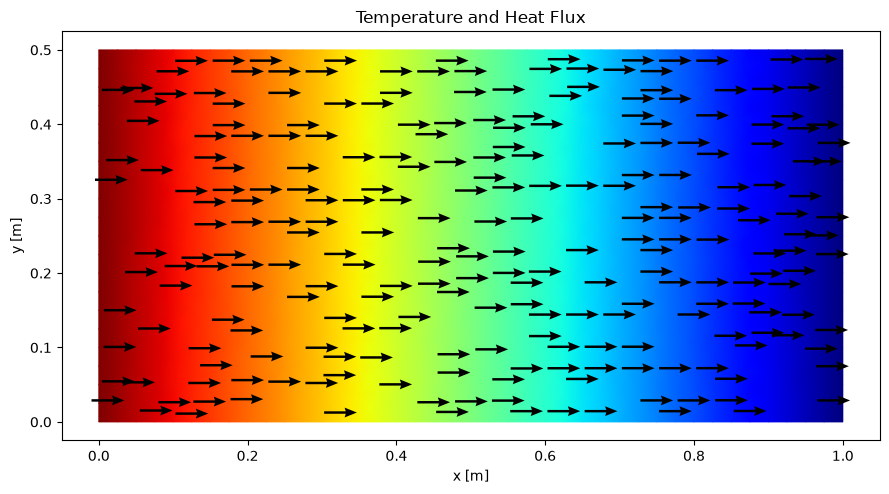

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from skfem.visuals.matplotlib import plot

# ------------------------------------------------------------
# Heat flux
# ------------------------------------------------------------

uh = basis.interpolate(T)

dT_dx = uh.grad[0]
dT_dy = uh.grad[1]

# Heat flux vector q = -k * grad(T)
qx = -k_iron_plate * dT_dx
qy = -k_iron_plate * dT_dy

# Average quadrature points -> one vector per element
qx_elem = qx.mean(axis=1)
qy_elem = qy.mean(axis=1)

q_mag = np.sqrt(qx_elem**2 + qy_elem**2)


# ------------------------------------------------------------
# Element centers
# ------------------------------------------------------------

x = mesh.p[0, mesh.t]
y = mesh.p[1, mesh.t]

centers_x = x.mean(axis=0)
centers_y = y.mean(axis=0)


# ------------------------------------------------------------
# Plot temperature
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5))

plot(
    basis,
    T,
    shading="gouraud",
    ax=ax
)

# ------------------------------------------------------------
# Normalize heat-flux vectors
# ------------------------------------------------------------

qx_norm = qx_elem / (q_mag + 1e-20)
qy_norm = qy_elem / (q_mag + 1e-20)


# ------------------------------------------------------------
# Plot fewer arrows
# ------------------------------------------------------------

step = 2

ax.quiver(
    centers_x[::step],
    centers_y[::step],
    qx_norm[::step],
    qy_norm[::step],
    color="black",
    pivot="mid",
    scale=25,
    width=0.003,
    headwidth=4,
    headlength=5
)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.set_aspect("equal")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Temperature and Heat Flux")

plt.tight_layout()
# plt.show()

print(f"Mean |q| = {np.mean(q_mag):.6f} W/m²")
print(f"Std  |q| = {np.std(q_mag):.6e} W/m²")

Heat flux is constant in whole plate as expected.

The analytical solution for heat flux is:
 
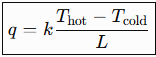

In [34]:
L = 1.0 # m
q_analytical = k_iron_plate * (T_left - T_right) / L
print(f"Analytical |q| = {q_analytical:.6f} W/m²")

Analytical |q| = 6400.000000 W/m²
